# AB Dor Visibility-Model Fit

Joint instrument + kernel-visibility fit of AB Dor and its calibrators from calslope data, modeled on `wr137_vis.ipynb` but without WR137's `MonthVisFit`/`WheelVisFit` time-binning subclasses -- AB Dor's calslope data is a single visit, so plain `amigo.model_fits.SplineVisFit` exposures are used directly. Updated for `amigo`'s `retrain` branch and the `v_0.0.11` amigo files cache. No `dorito` dependency.

This fits `amigo.vis_models.LogVisModel` amplitude/phase basis coefficients jointly with the instrument model (aberrations, positions, fluxes, spectra) across all AB Dor + calibrator exposures. The resulting per-exposure amplitudes/phases are the calibrated kernel visibilities that feed into an OI-based reconstruction (e.g. `ab-dor.ipynb`).

**Note:** fixing this against dLux 0.15 required a one-line fix in `amigo/src/amigo/vis_models.py` (`wf_fft_coords` was assuming `wfs.pixel_scale` is a scalar; under dLux 0.15 it's a per-wavelength vector, constant in value).

In [ ]:
# jax ecosystem
import jax

jax.config.update("jax_enable_x64", True)

device = jax.local_devices()[0]
print(device.device_kind)

from jax import numpy as np, random as jr, tree as jtu
import os

from amigo.fitting import sgd, adam  # moved from zodiax.optimisation

import amigo

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

In [ ]:
from socket import gethostname

print(gethostname())
if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/research-data/PRJ-PAT/max/data/JWST/"
    cache_dir = "/Volumes/research-data/PRJ-PAT/max/data/amigo_cache"
    amigo_files_path = "/Volumes/research-data/PRJ-PAT/max/data/amigo_files/v_0.0.11"
    # output_path = "/Users/mc/nt_outputs/local_retrain"

elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    cache_dir = "/home/dgxuser/max/data/amigo_cache"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.11"
    # output_path = "/home/dgxuser/max/outputs/retrain"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.11"
    # output_path = "/fred/oz440/max/outputs/retrain"


uncal_data_dir = os.path.join(data_dir, "AB-DOR/uncal/")
data_dir = os.path.join(data_dir, "AB-DOR/calslope/")
# output_path = os.path.join(amigo_cache, "outputs/AB-DOR/")

n_files_per_filt = 1  # max out at 25 (HD-36805's F480M dither sequence)
one_filt_flag = True  # if True, only use F480M
pos1_only = False
n_epoch = 100
save_path = None
pipeline_flag = False
intermediate_prints = []
# intermediate_prints = [25, 50, 100, 150]
# intermediate_prints = [e for e in intermediate_prints if e < n_epoch]

# TARGPROP values in the data: science target is "AB-DOR", PSF calibrators are
# "HD-37093" and "HD-36805" (see chromatic_psf.ipynb).
EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    "F430M",
    "F380M",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

max-vscode-gpu-0-2


In [ ]:
import importlib

# Same shared bad-pixel map used in retrain.ipynb
resource_path = importlib.resources.files(amigo).joinpath("data/badpix.npy")
with importlib.resources.as_file(resource_path) as file_path:
    badpix = np.array(np.load(file_path), dtype=int)
badpix_bool = badpix.astype(
    bool
)  # use for boolean masking; badpix (int) is kept for FITS writing


def add_badpix(file):
    file["BADPIX"].data = badpix
    if file[0].header["EXP_TYPE"] == "NIS_DARK":
        file["BADPIX"].data[25, 74] = 1
    return file

In [ ]:
from amigo.misc import get_pos

# Same file-sorting convention as retrain.ipynb: prefer POS1 dithers (falling
# back to interleaved POS1/POS2), grouped by filter, truncated to at most `n`
# files per filter.
# Quick toggle flags -- controls how much data goes into the fit.


def sort_files(files, n):
    files.sort(
        key=lambda x: (
            x[0].header["PROGRAM"],
            x[0].header["FILTER"],
            x[0].header["PATT_NUM"],
        ),
        reverse=True,
    )
    filts = ["F480M", "F430M", "F380M"]
    these_files = {}

    for filt in filts:
        if one_filt_flag and filt != "F480M":
            these_files[filt] = []
            continue

        matched = [f for f in files if f[0].header["FILTER"] == filt]

        if pos1_only:
            x = [f for f in matched if get_pos(f) == "POS1"]
        else:
            pos1 = [f for f in matched if get_pos(f) == "POS1"]
            pos2 = [f for f in matched if get_pos(f) == "POS2"]
            x = []
            for a, b in zip(pos1, pos2):
                x.extend([a, b])
            x.extend(pos1[len(pos2) :])
            x.extend(pos2[len(pos1) :])

        these_files[filt] = x[0:n]

    files = [f for sub_f in these_files.values() for f in sub_f]
    return files

# Loading in data

In [ ]:
from retrain_fns import summarise_files
from amigo.pipelines import process_calslope

if pipeline_flag:
    process_calslope(uncal_data_dir, data_dir)

# The known PSF calibrators for this program (see chromatic_psf.ipynb). A
# handful of single-frame acquisitions for other targets (e.g.
# "J062802.01-663738.0") also show up as IS_PSF=True in this folder; their
# TARGPROP contains a literal "." which breaks amigo's dotted param-key
# lookup, so they're excluded explicitly rather than accepted via IS_PSF alone.
CALIBRATORS = ["HD-37093", "HD-36805"]

sci_files = sort_files(file_fn(data_dir, IS_PSF=False), n=n_files_per_filt)
cal_files = sort_files(file_fn(data_dir, IS_PSF=True), n=n_files_per_filt)
cal_files = [f for f in cal_files if f[0].header["TARGPROP"] in CALIBRATORS]

sci_files = [add_badpix(f) for f in sci_files]
cal_files = [add_badpix(f) for f in cal_files]

summarise_files(sci_files)
summarise_files(cal_files)

  program  target filter dither   g/i        date                 PI    CAL
0    1093  AB-DOR  F480M    5/5  5/69  05-06-2022  Thatte, Deepashri  False
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  25/25  9/65  05-06-2022  Thatte, Deepashri  True


# Building the model

In [ ]:
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()

state = load_dict(amigo_files_path + "/calibration.npy")
best_state = load_dict(amigo_files_path + "/final_statev45.npy")
cache_state = load_dict(cache_dir + "/AB-DOR/scratch_final_state.npy")

cal_exposures = [amigo.model_fits.SplineVisFit(file) for file in cal_files]
sci_exposures = [amigo.model_fits.SplineVisFit(file) for file in sci_files]
exposures = cal_exposures + sci_exposures

model = amigo.core_models.AmigoModel(
    exposures,
    optics=amigo.optical_models.AMIOptics(sparse=True, radial_orders=4),
    detector=amigo.detector_models.LinearDetector(),
    ramp_model=amigo.ramp_models.NonLinearRamp(),
    read=amigo.read_models.ReadModel(per_pixel_dark=True),
    vis_model=amigo.vis_models.LogVisModel(load_dict(amigo_files_path + "/vis_basis.npy")),
    # state=state,
)

for param in [
    "nn_weights",
    "FF",
    "non_linearity",
    "defocus",
    "sigma",
    "transmission",
    "dark_current",
]:
    model = model.set(param, best_state[param])

for param in [
    "positions",
    "fluxes",
    "aberrations",
    "spectra",
]:
    model = model.set(param, cache_state[param])


01093_F480M
File 01093_020_02_03_25
Star HD-36805
Filter F480M
nints 65
ngroups 9



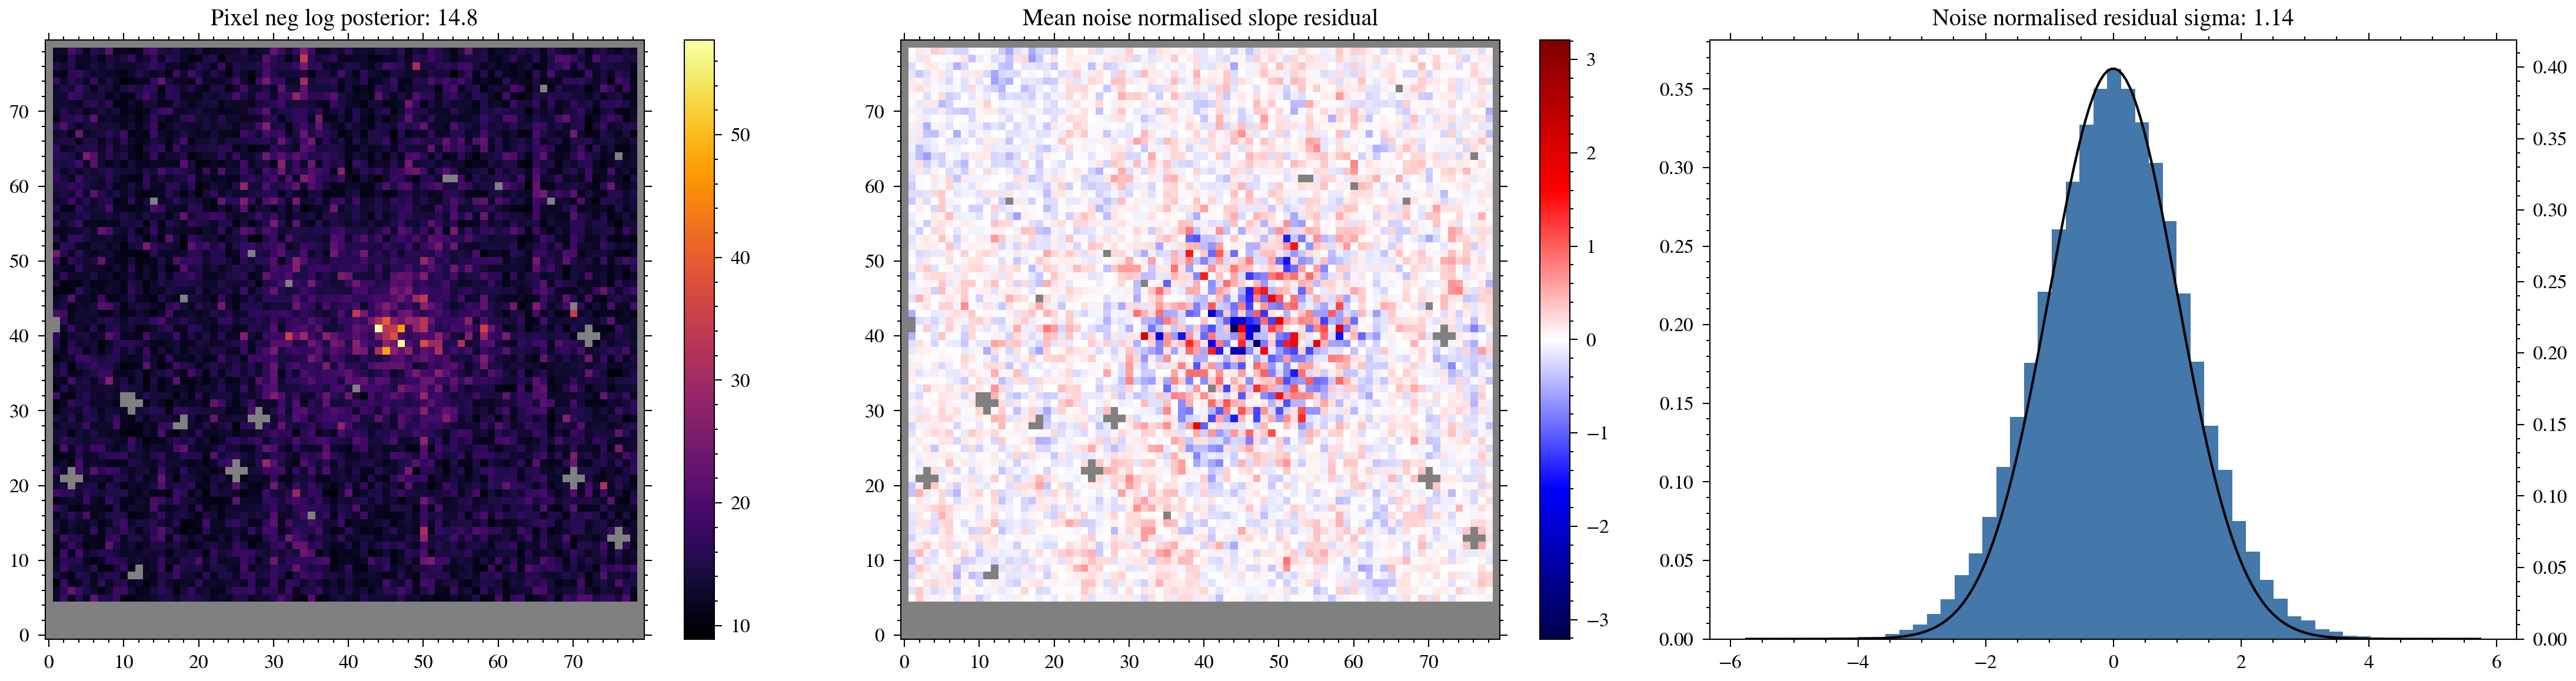

01093_F480M
File 01093_014_02_03_5
Star AB-DOR
Filter F480M
nints 69
ngroups 5



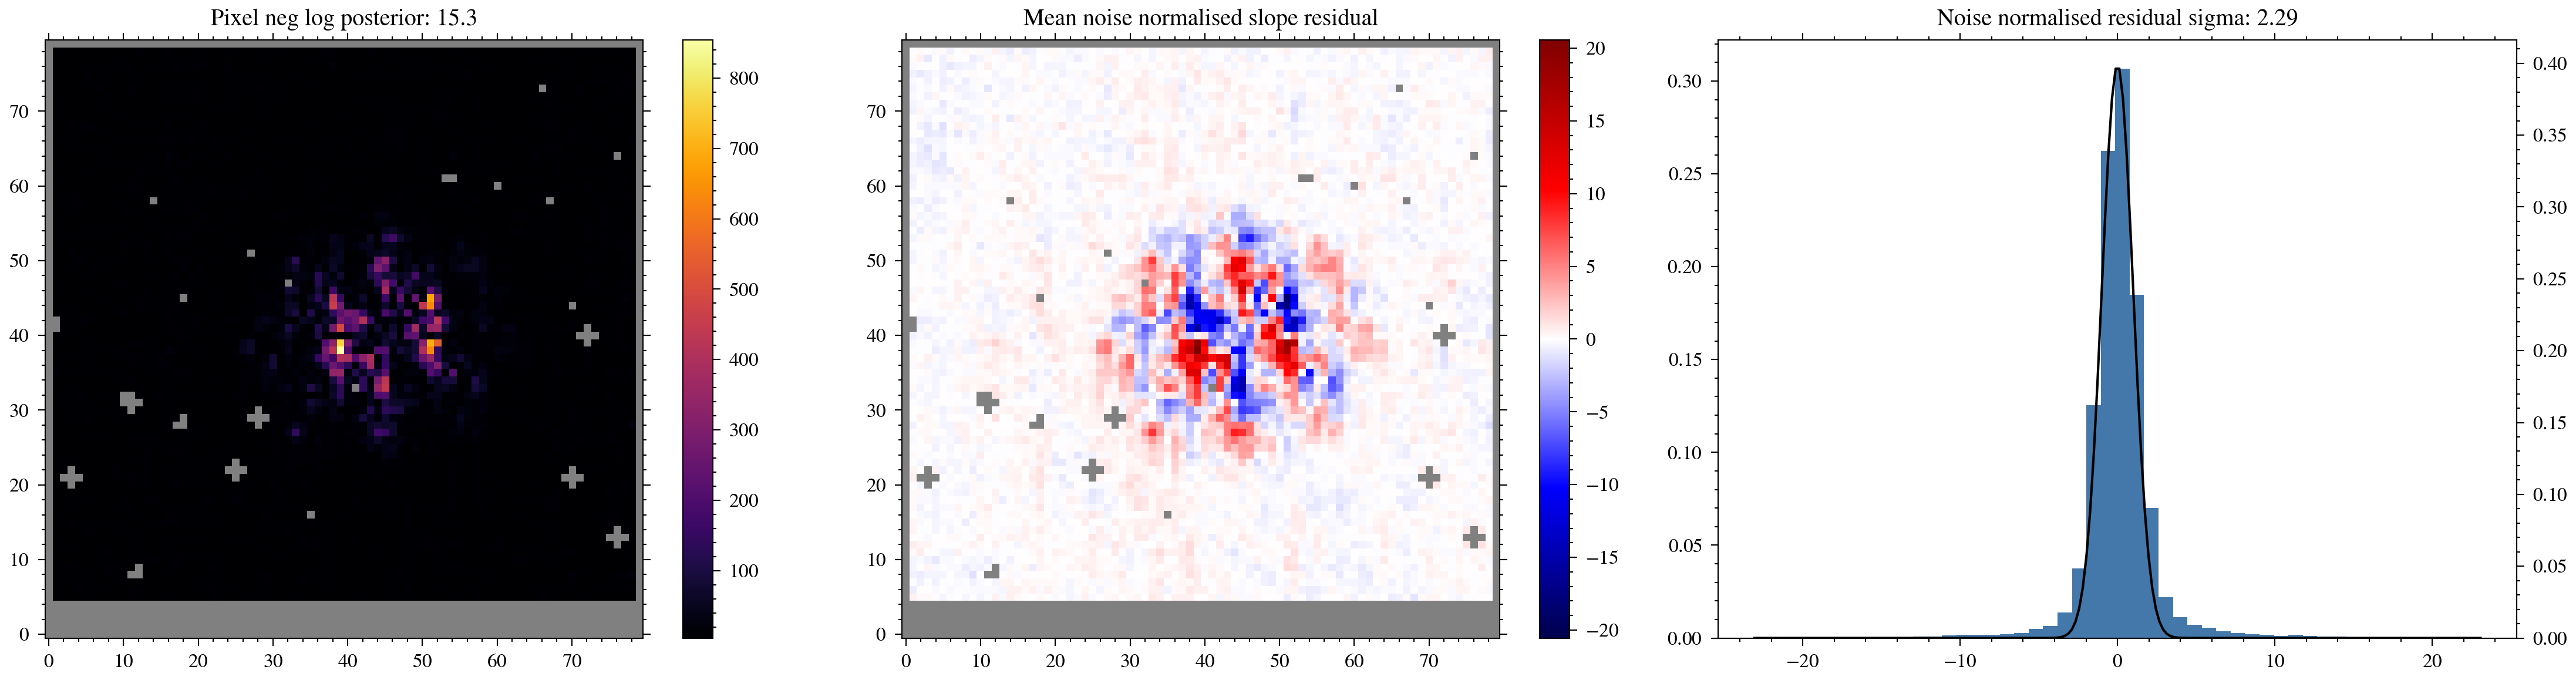

In [ ]:
for exp in exposures:
    print(exp.get_key("aberrations"))
    exp.print_summary()
    amigo.plotting.summarise_fit(model, exp, residuals=False, top_group=False)

# Optimisation

In [ ]:
def summarise_fn(result, save_path, optimisers):
    losses = np.array([v for v in result.losses.values()]).mean(0)
    amigo.plotting.plot_losses(
        losses, start=int(0.8 * len(losses)), save_path=save_path
    )
    amigo.plotting.plot(result.history, save_path=save_path)

    for exp in exposures:
        exp.print_summary()
        amigo.plotting.summarise_fit(result.model, exp, save_path=save_path)

    pupil_mask = result.model.optics.pupil_mask
    
    rms = lambda x: np.sqrt(np.nanmean(np.square(x)))
        
    if "aberrations" in optimisers.keys():
        for key, coeffs in result.state.aberrations.items():
    
            # trying to get the program and filter strings
            key_split = key.split("_")
            if len(key_split) > 2:
                filt, prog = key_split[0], key_split[1]
            elif len(key_split) == 2:
                prog, filt = key_split
    
            # plotting
            fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
    
            full_abb = pupil_mask.set("abb_coeffs", coeffs).calc_aberrations()
            flat_abb = pupil_mask.set("abb_coeffs", coeffs.at[:, :3].set(0)).calc_aberrations()
            
            mask = result.model.optics.transmission
        
            full_abb = np.where(mask < 1.0, np.nan, 1e9 * full_abb)
            flat_abb = np.where(mask < 1.0, np.nan, 1e9 * flat_abb)
        
            full_abb -= np.nanmean(full_abb)
            flat_abb -= np.nanmean(flat_abb)
        
            ax[0].set_title(f"{key} — Full OPD (RMS: {rms(full_abb):.2f} nm)")
            im_top = ax[0].imshow(full_abb, cmap=seismic, norm=mpl.colors.CenteredNorm())
            fig.colorbar(im_top, ax=ax[0], label="OPD (nm)")
        
            ax[1].set_title(f"{key} — FLAT OPD (RMS: {rms(flat_abb):.2f} nm)")
            im_bot = ax[1].imshow(flat_abb, cmap=seismic, norm=mpl.colors.CenteredNorm())
            fig.colorbar(im_bot, ax=ax[1], label="OPD (nm)")
    
    
            fig.tight_layout()
            # if save_flag:
            #     if save_path is not None:
            #         this_save_path = os.path.join(save_path, "wavefronts/")
            #         if not os.path.exists(this_save_path):
            #             os.mkdir(this_save_path)
            #     else:
            #         this_save_path = None
                    
            #     plt.savefig(os.path.join(this_save_path, f"{prog}_{filt}_{key}.png"), dpi=300)
            #     plt.close()
            # else:
            #     plt.show()
            plt.show()

In [ ]:
trainer.update_fishers?

Object `trainer.update_fishers` not found.


In [ ]:
config = {
    "positions": sgd(2e-1, 0),
    "fluxes": sgd(2e-1, 0),
    "aberrations": sgd(5e-2, 3),
    "spectra": sgd(2e-1, 20),
    "phases": sgd(1e-3, 20),
    "amplitudes": sgd(1e-3, 20),
}

trainer = amigo.fitting.Trainer(
    cache=os.path.join(cache_dir, "fishers/"),
    summarise_fn=summarise_fn,
    intermediate_prints=intermediate_prints,
    save_path=save_path,
)

# trainer = trainer.populate_fishers(
trainer = trainer.update_fishers(
    model,
    exposures,
    # hessians=load_dict(amigo_files_path + "/jacobians.npy")["hessian"],
    parameters=list(config.keys()),
    # batch_size=2,
)

print("Number of exposures: ", len(exposures))

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=exposures,
)

  0%|          | 0/2 [00:00<?, ?it/s]

Number of exposures:  2


  0%|          | 0/100 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 15.66
Estimated run time: 0:00:47
Full Time: 0:01:10
Final Loss: 15.45


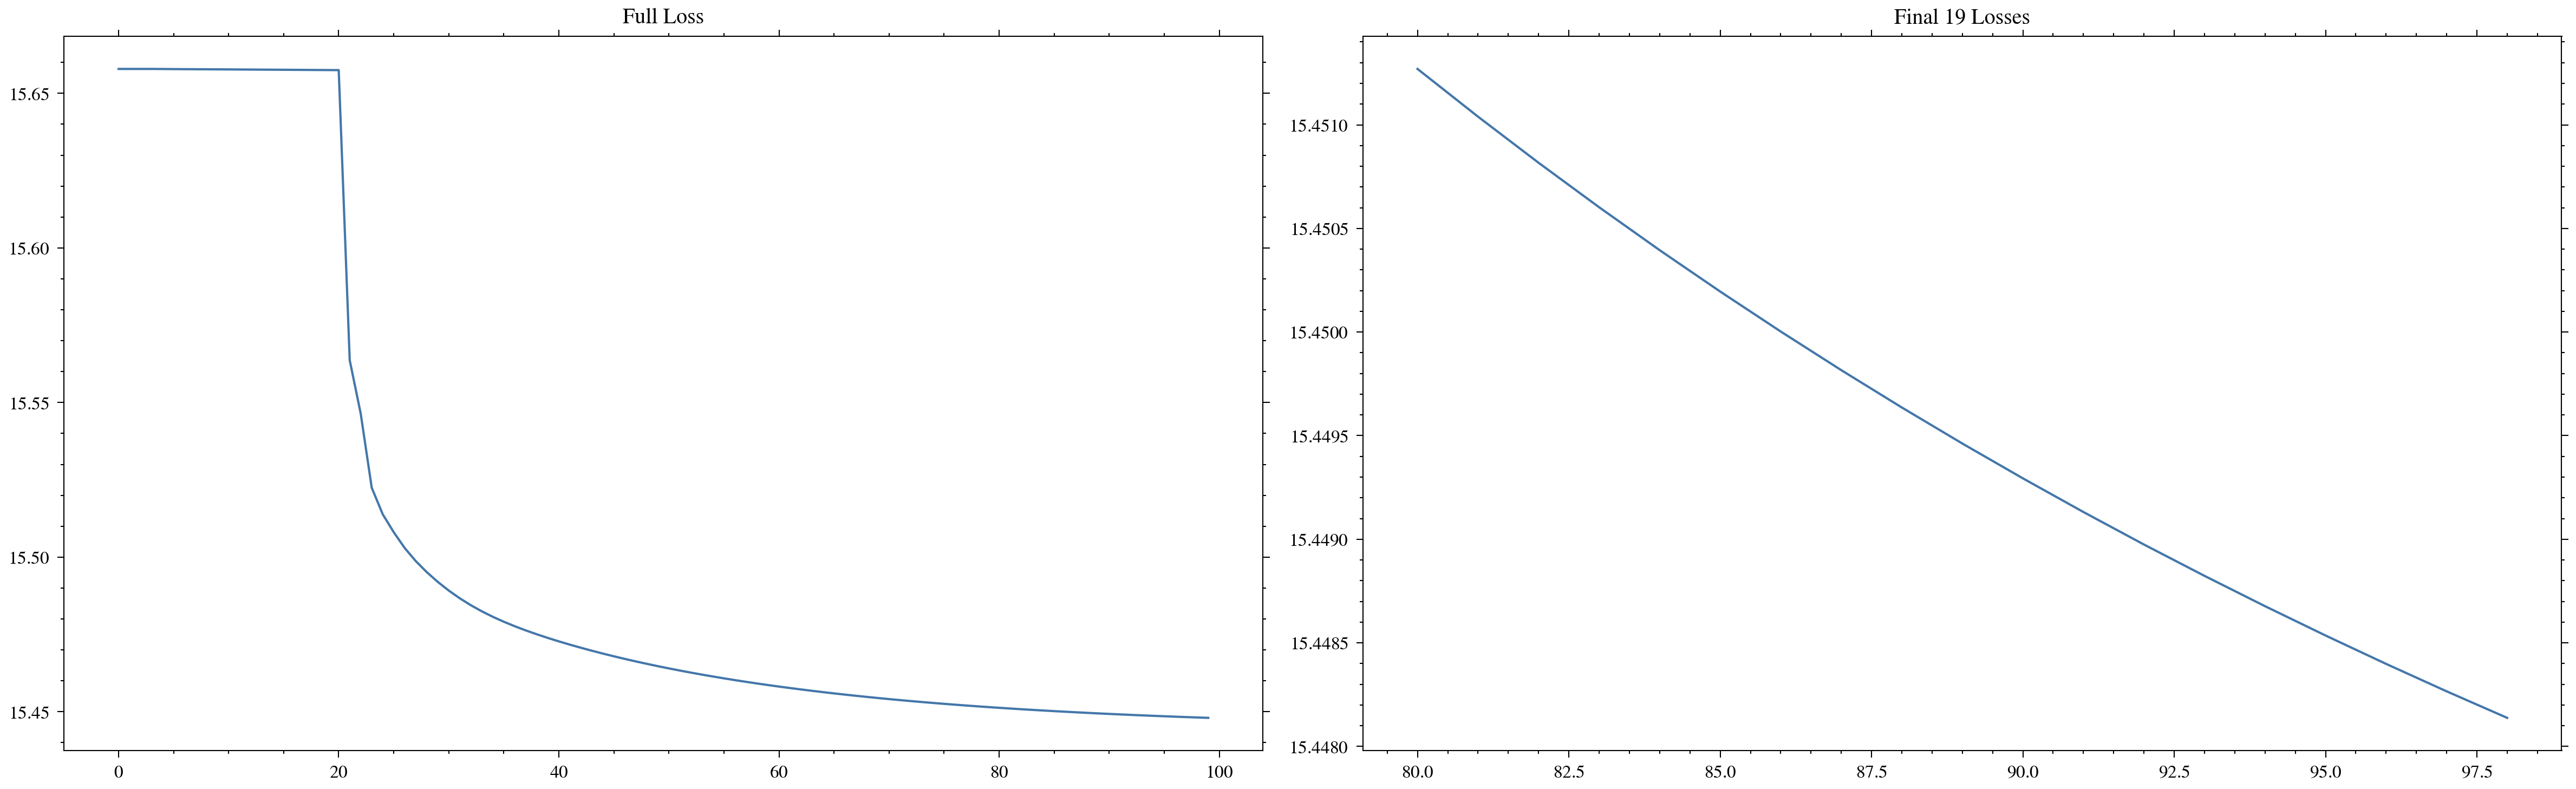

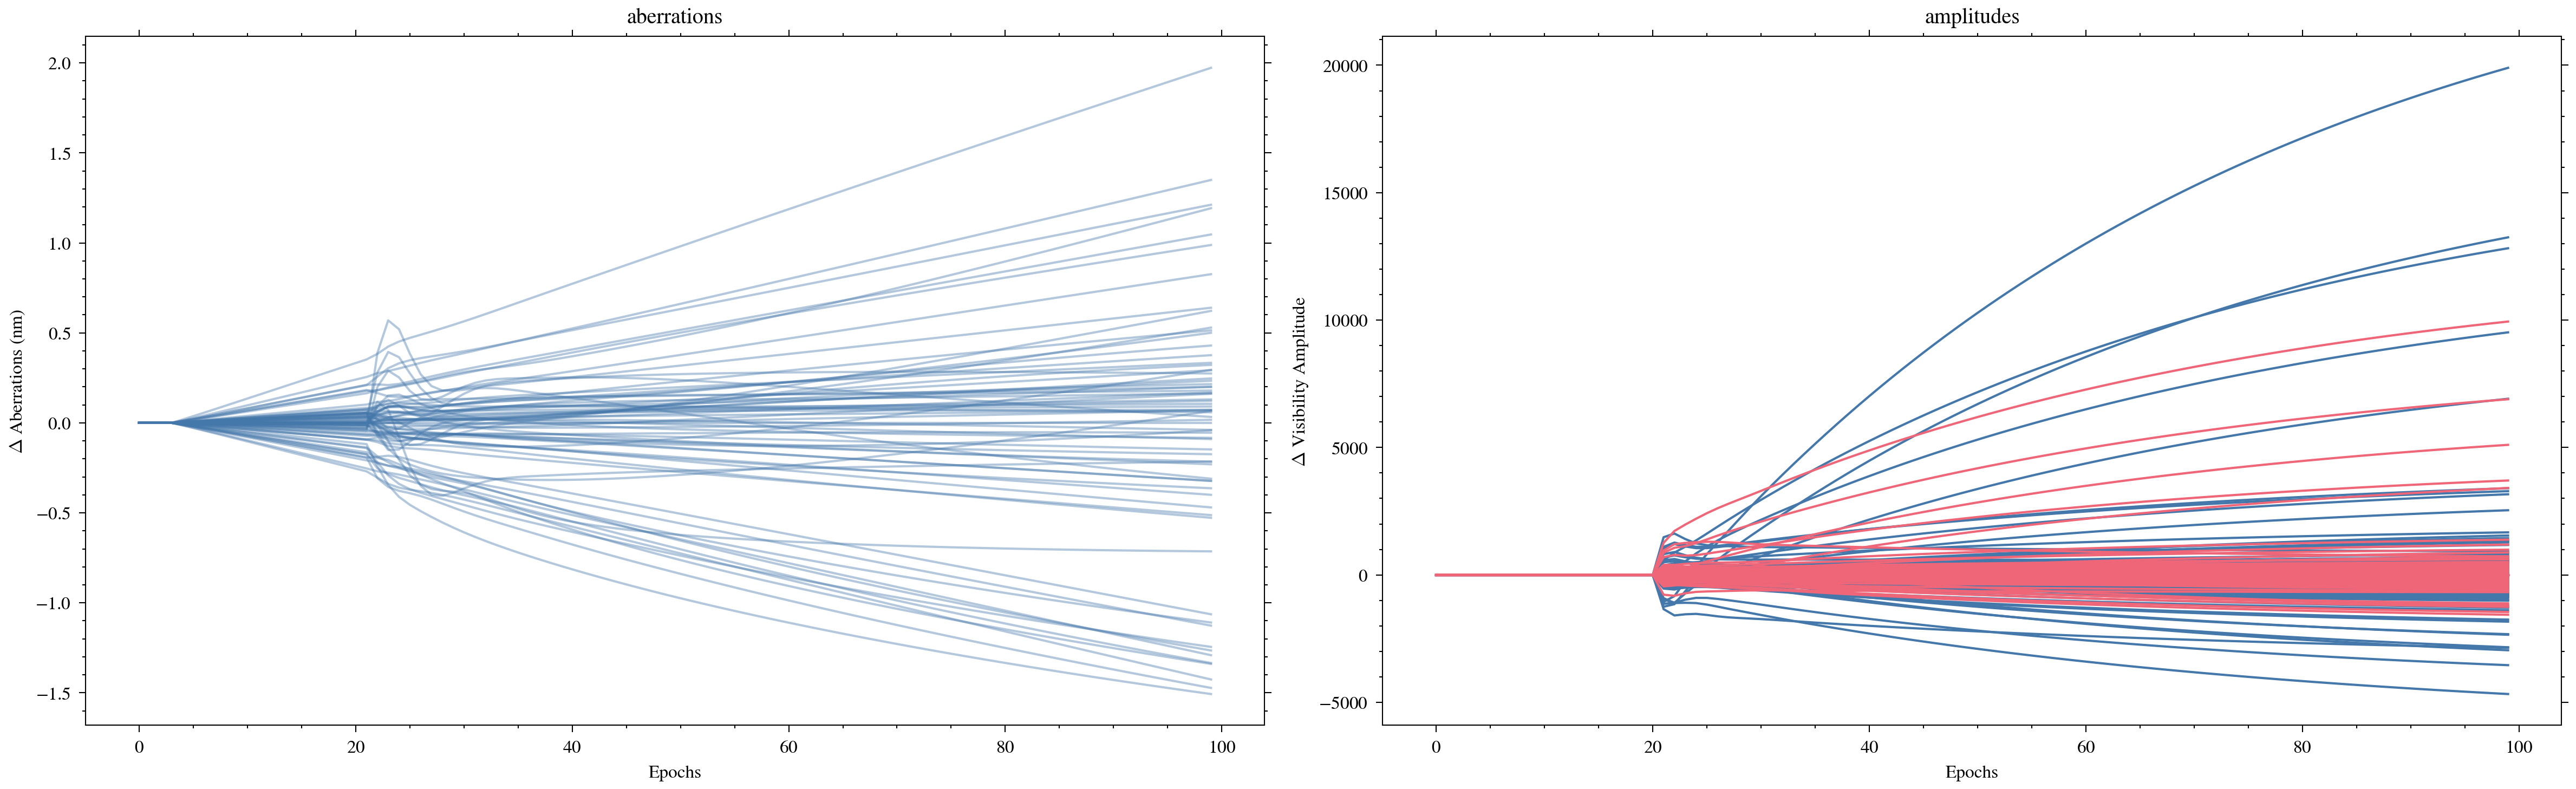

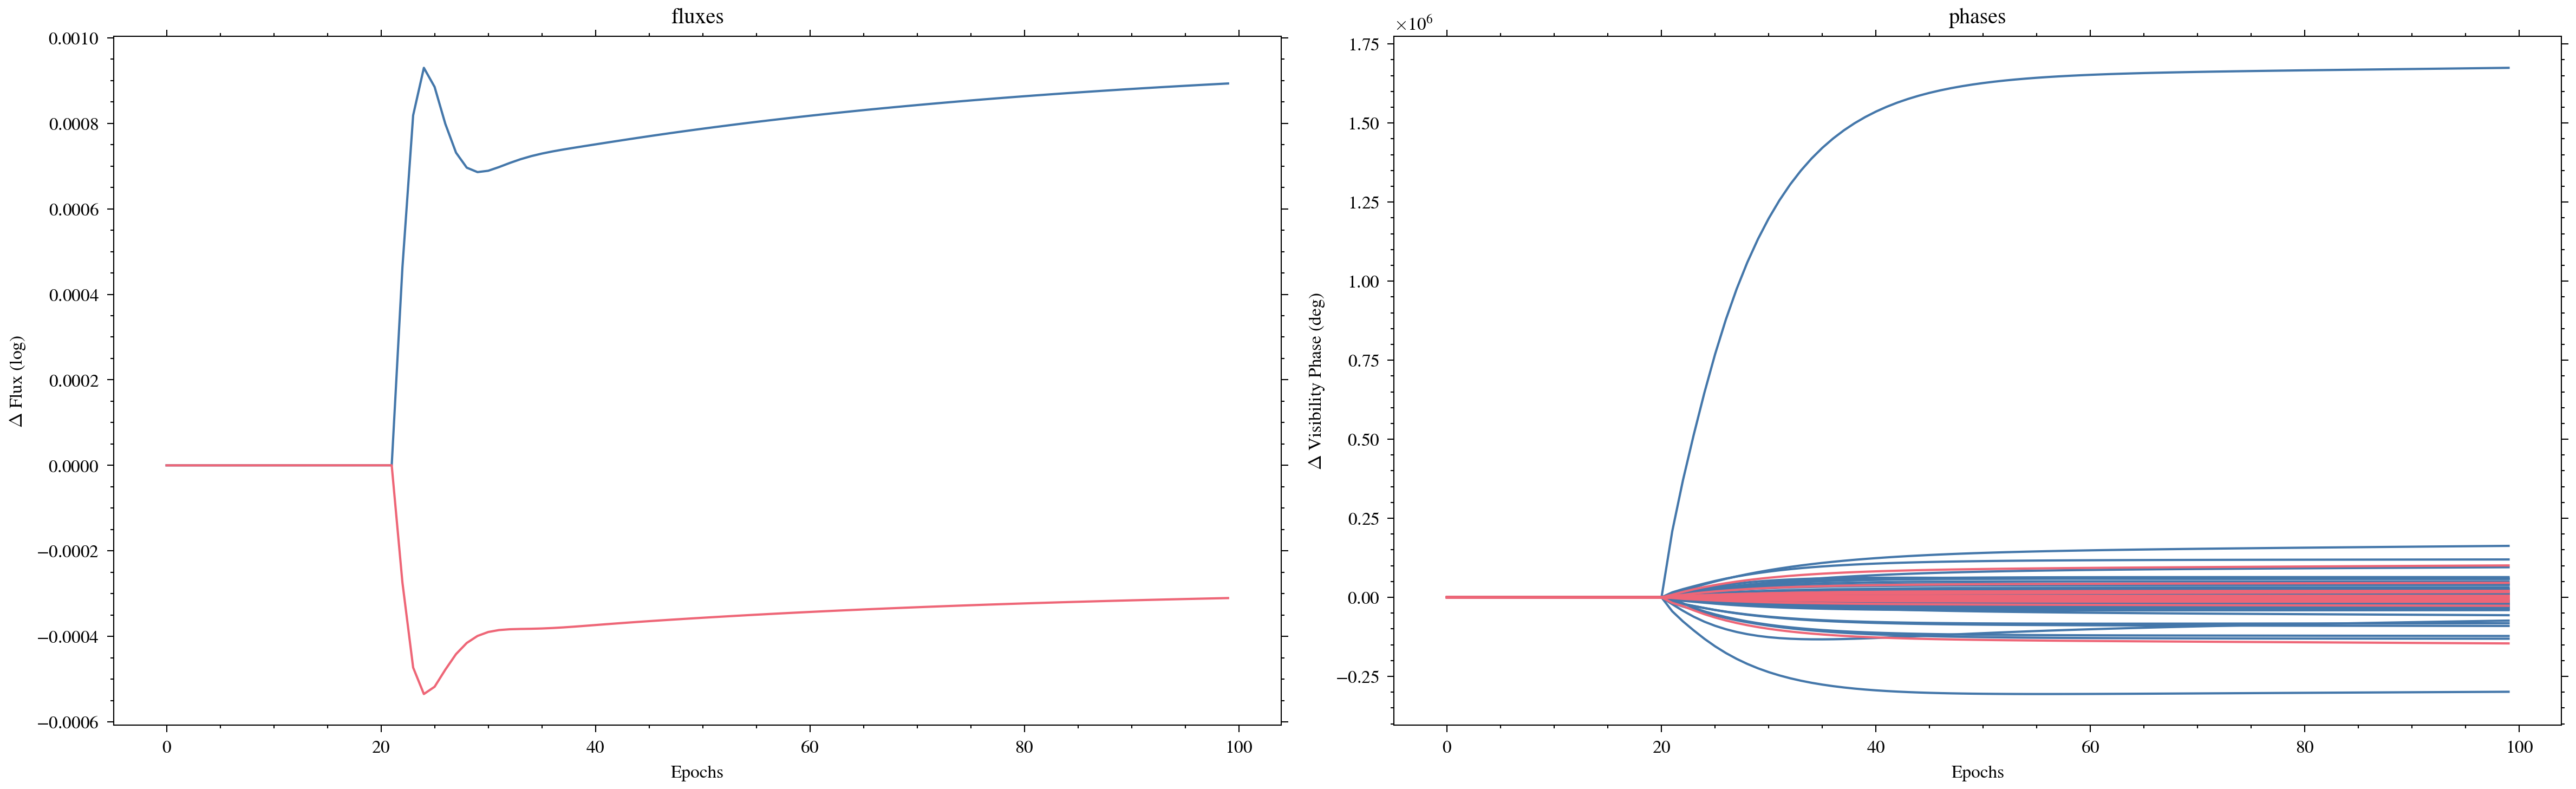

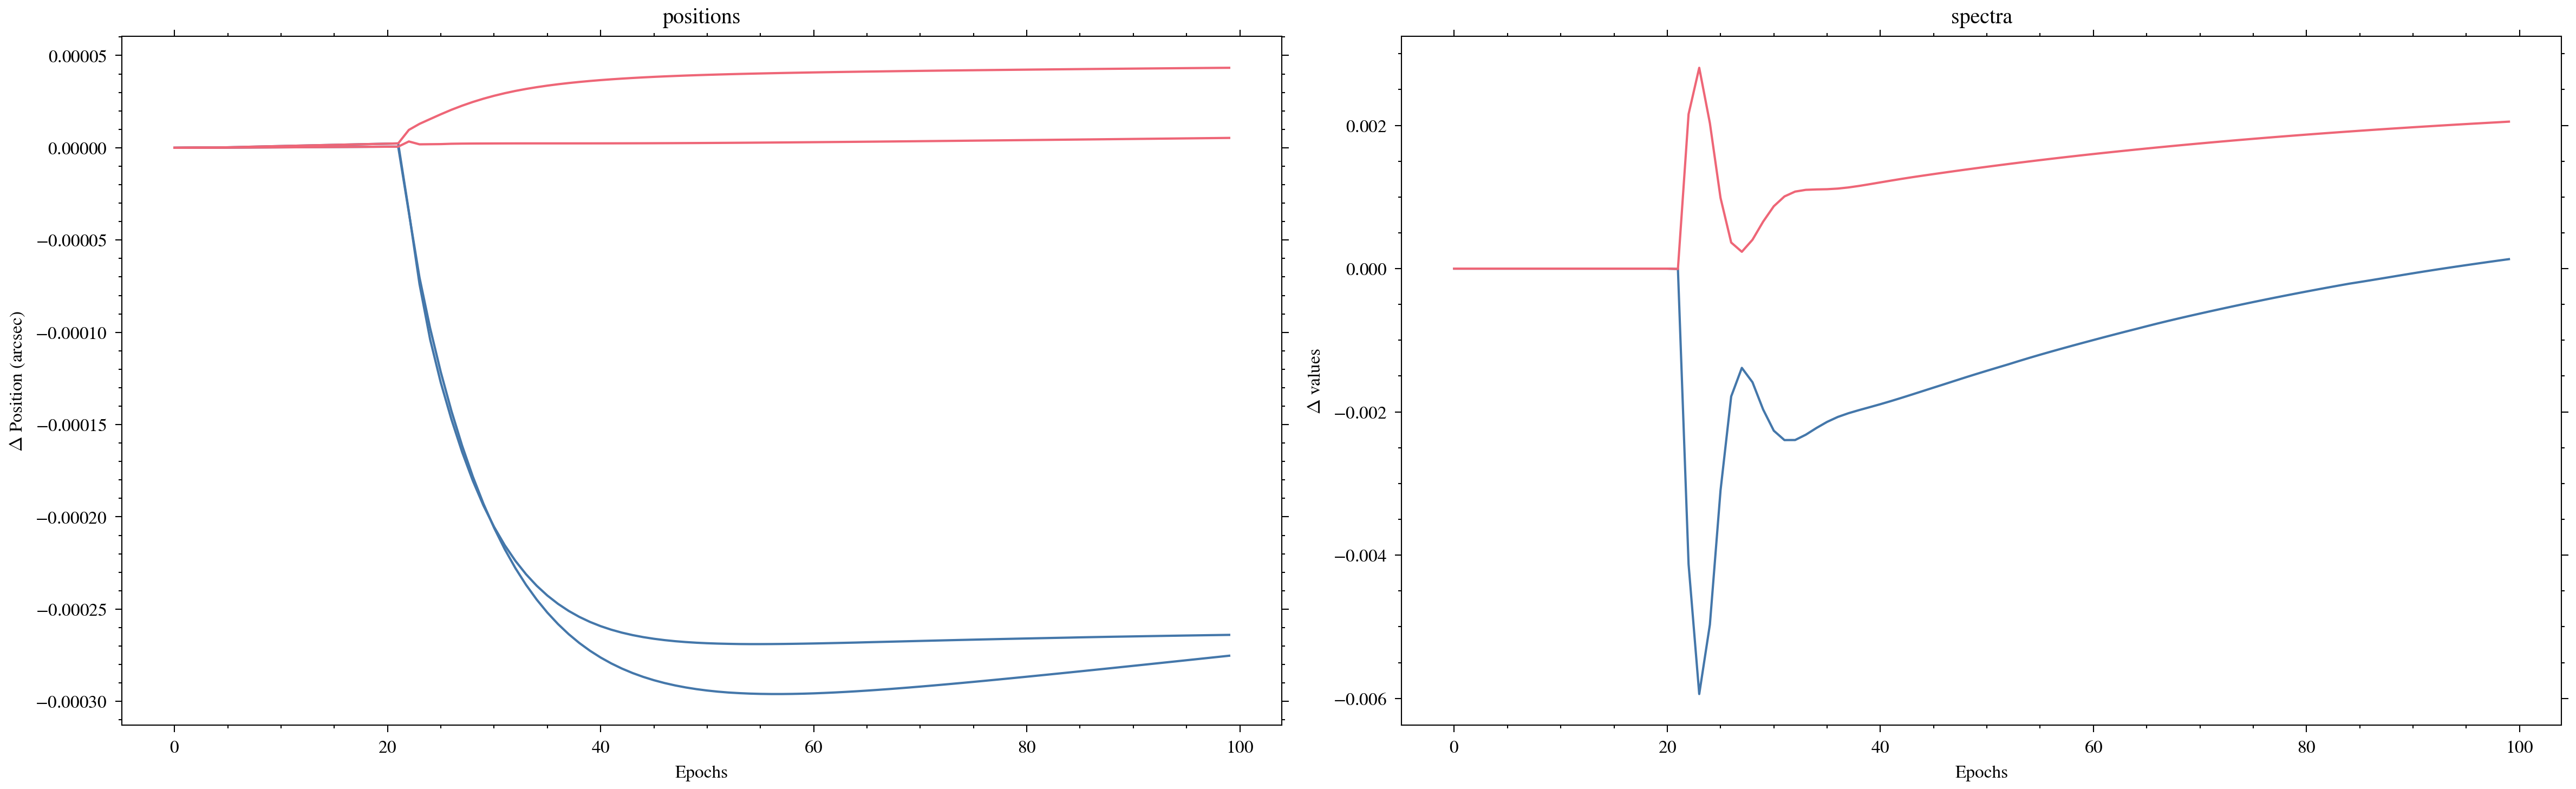

File 01093_020_02_03_25
Star HD-36805
Filter F480M
nints 65
ngroups 9



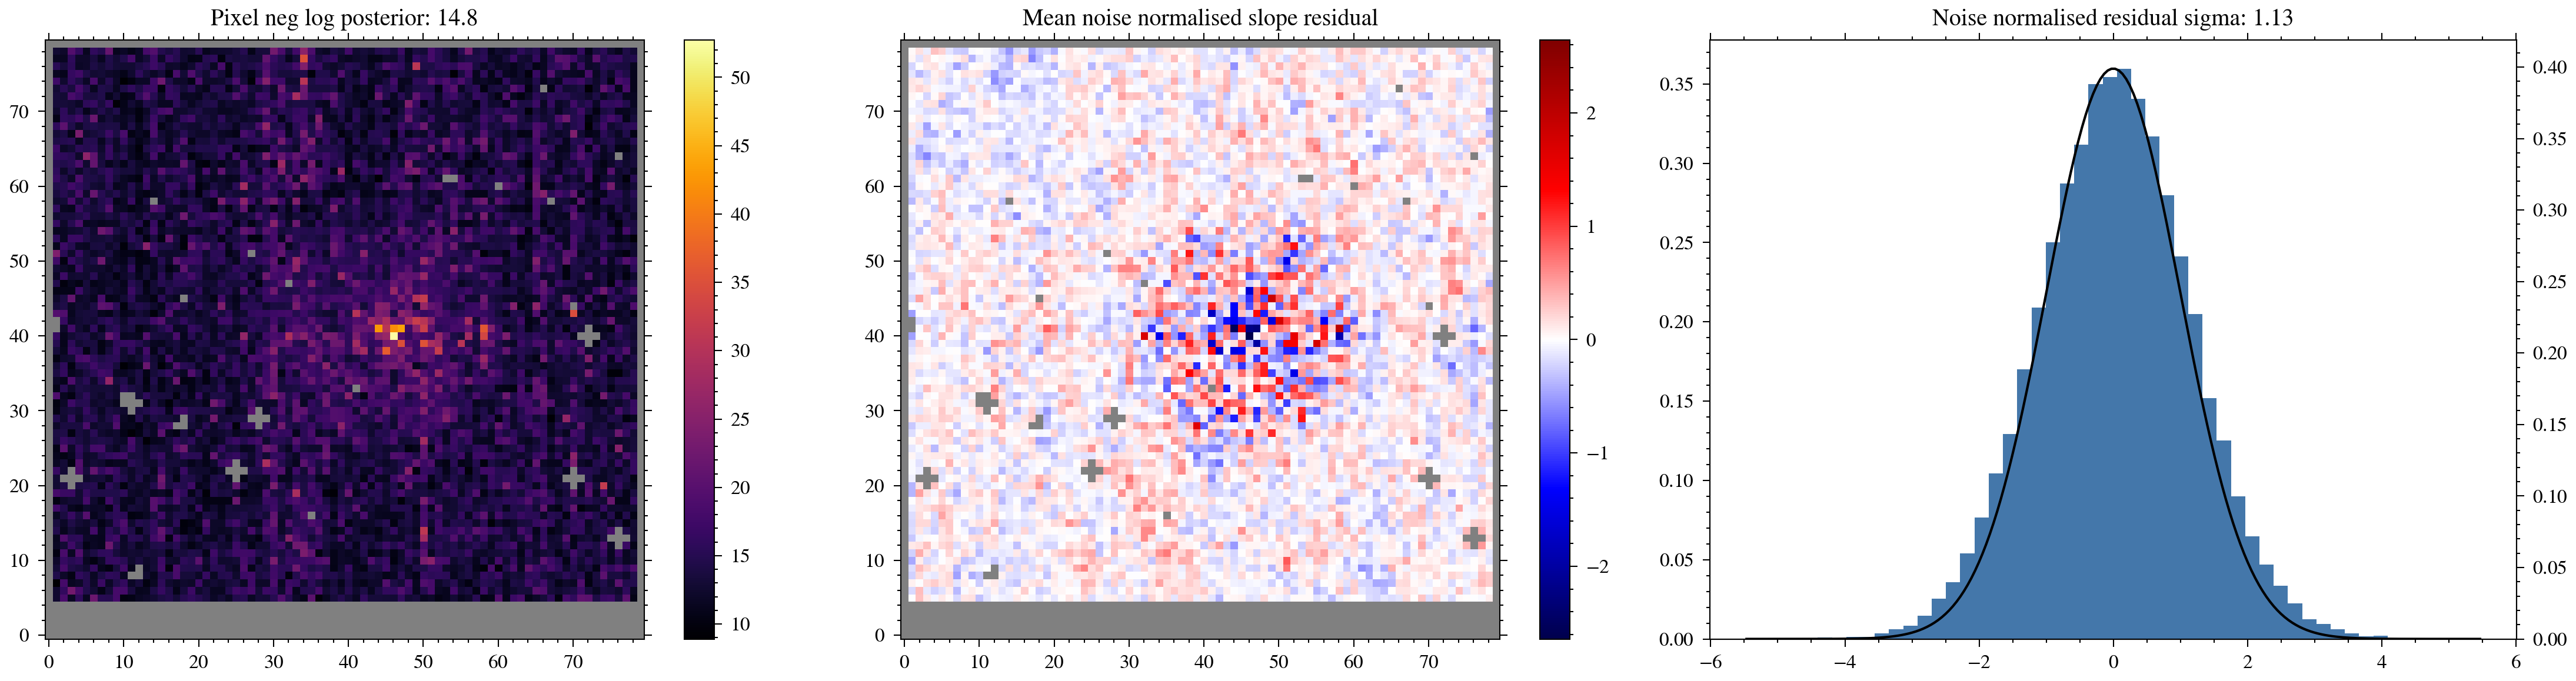

File 01093_014_02_03_5
Star AB-DOR
Filter F480M
nints 69
ngroups 5



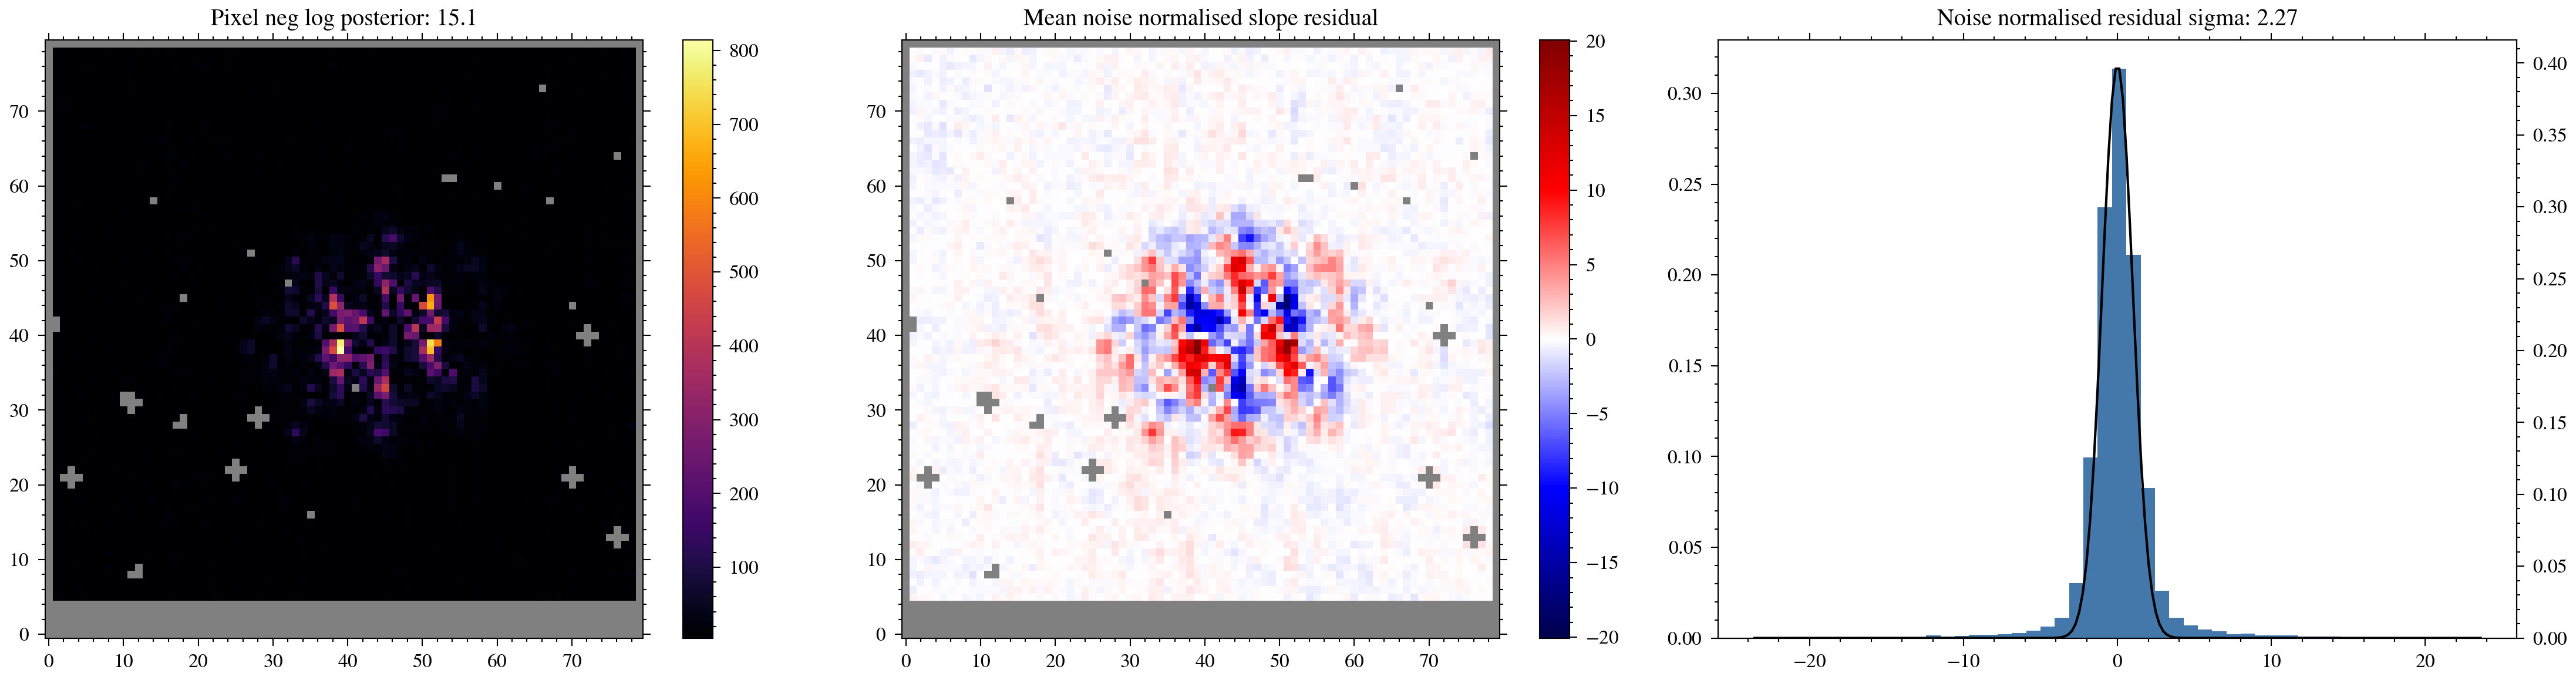

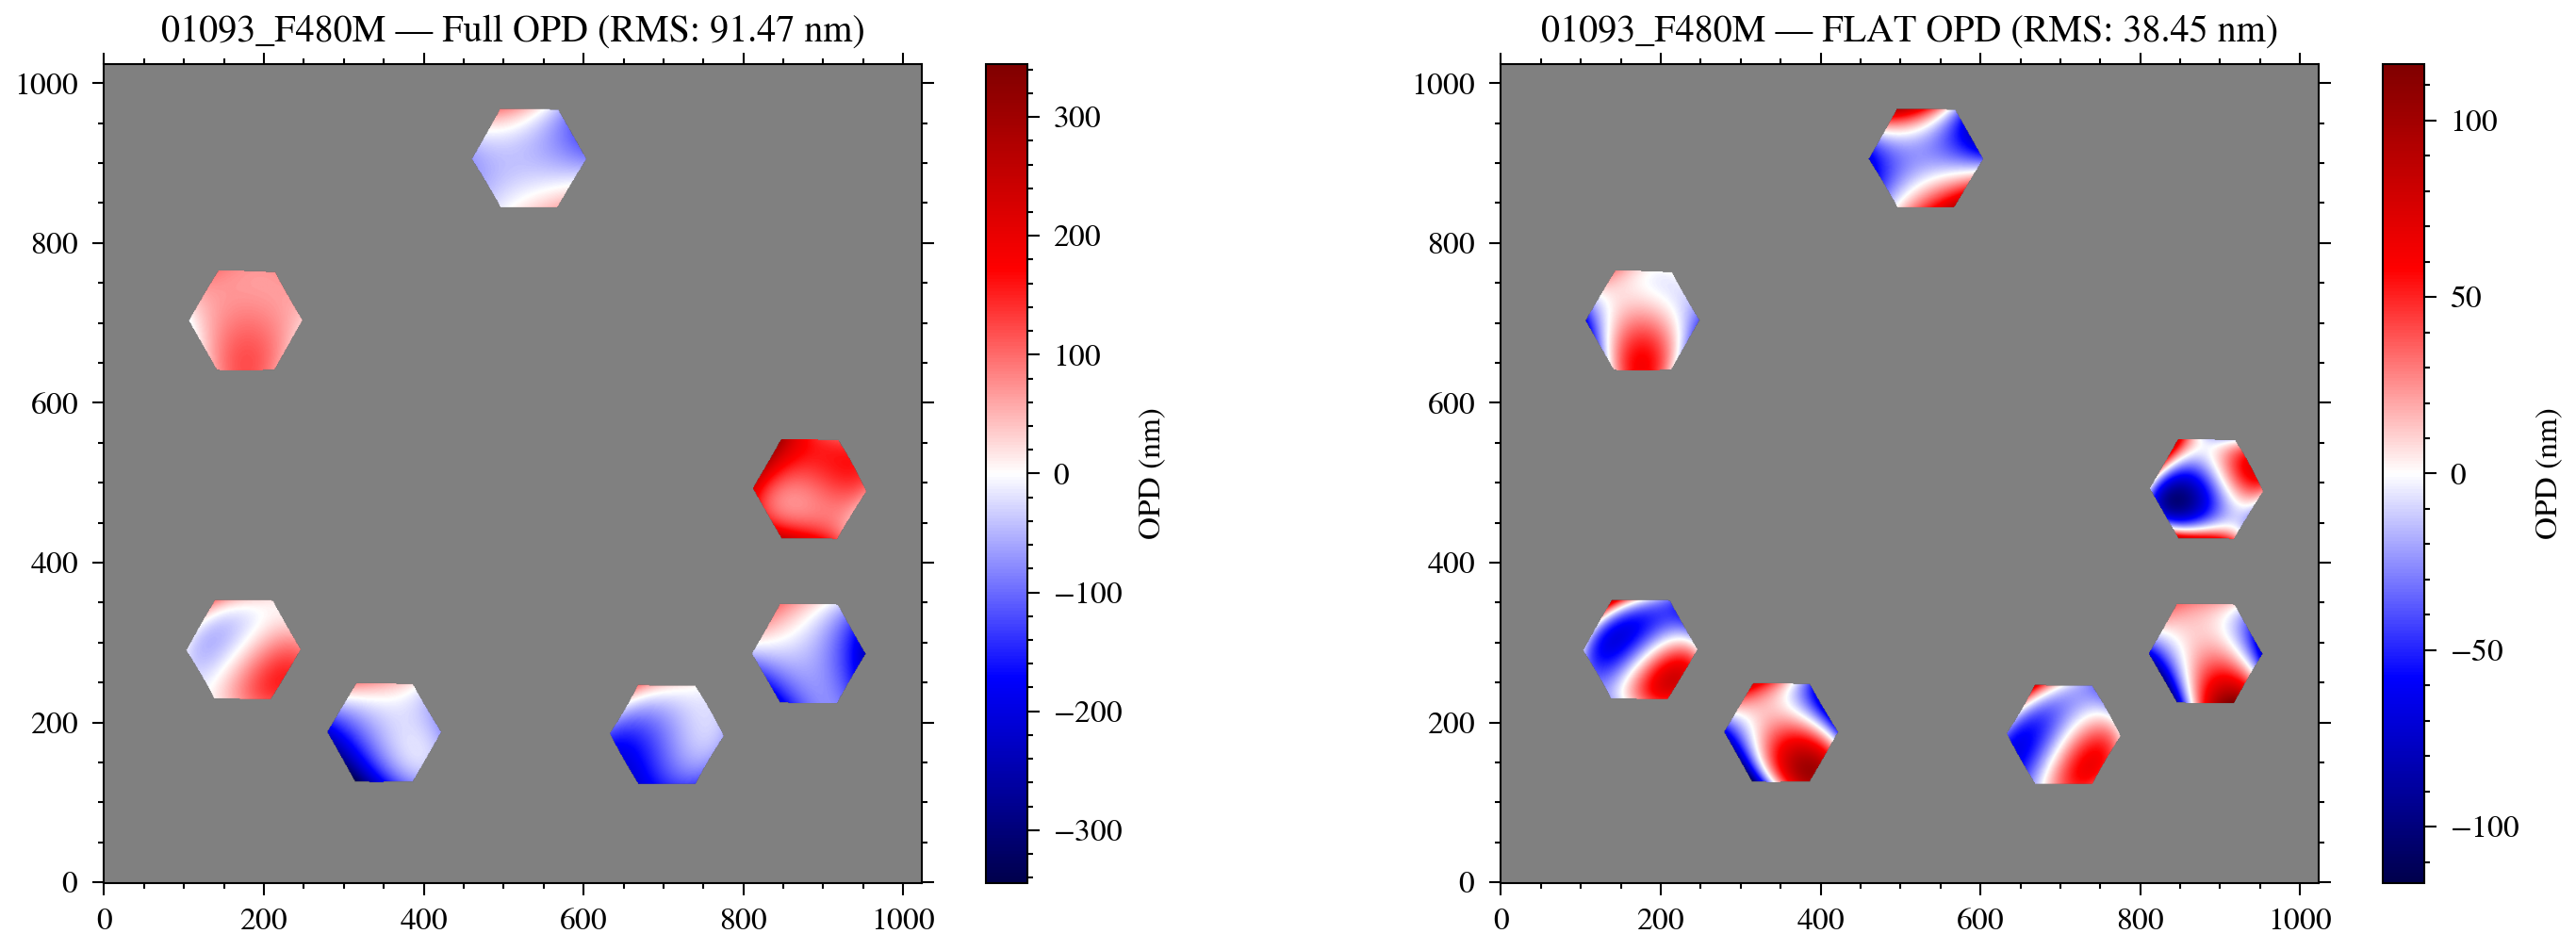

In [ ]:
# np.save(os.path.join(cache_dir, "AB-DOR/scratch_final_state.npy"), result.state.params, allow_pickle=True)

summarise_fn(result, save_path, config)